In [4]:
pip install numpy scipy matplotlib

In [1]:
# physics_core.py
import numpy as np
import scipy.sparse as sp

def get_operator(op, site, L):
    I = sp.csr_matrix(np.eye(2))
    op_list = [I] * L
    op_list[site] = op
    full_op = op_list[0]
    for i in range(1, L):
        full_op = sp.kron(full_op, op_list[i], format='csr')
    return full_op

def build_hamiltonian(L, J, Delta, W):
    I = sp.csr_matrix(np.eye(2))
    sigma_x = sp.csr_matrix([[0, 1], [1, 0]])
    sigma_y = sp.csr_matrix([[0, -1j], [1j, 0]])
    sigma_z = sp.csr_matrix([[1, 0], [0, -1]])

    dim = 2**L
    H = sp.csr_matrix((dim, dim))

    for i in range(L - 1):
        Sx_i = get_operator(sigma_x, i, L)
        Sx_j = get_operator(sigma_x, i+1, L)
        Sy_i = get_operator(sigma_y, i, L)
        Sy_j = get_operator(sigma_y, i+1, L)
        Sz_i = get_operator(sigma_z, i, L)
        Sz_j = get_operator(sigma_z, i+1, L)
        H += J * (Sx_i.dot(Sx_j) + Sy_i.dot(Sy_j) + Delta * Sz_i.dot(Sz_j))

    np.random.seed(42)
    h_fields = np.random.uniform(-W, W, L)
    for i in range(L):
        Sz_i = get_operator(sigma_z, i, L)
        H += h_fields[i] * Sz_i

    return H

def generate_sz0_basis(L):
    """Finds all binary numbers from 0 to 2^L that have exactly L//2 ones."""
    basis = []
    for i in range(2**L):
        if bin(i).count('1') == L // 2:
            basis.append(i)
    return basis

def diagonalize(H_full, L):
    """Slices the Hamiltonian to the Sz=0 sector, diagonalizes, and maps back."""
    basis = generate_sz0_basis(L)

    # 1. Convert to dense array to easily slice it
    H_dense = H_full.toarray()

    # 2. Extract the 252 x 252 submatrix!
    H_sub = H_dense[np.ix_(basis, basis)]

    print(f"Diagonalizing reduced Hamiltonian of size {len(basis)}x{len(basis)}...")
    E, V_sub = np.linalg.eigh(H_sub)

    # 3. V_sub is 252x252. We map these back to 1024-length vectors.
    # This ensures our entanglement entropy and observable math still works!
    V_full = np.zeros((2**L, len(E)))
    for n in range(len(E)):
        V_full[basis, n] = V_sub[:, n]

    return E, V_full

In [10]:
# diagnostics.py
import numpy as np
import scipy.sparse as sp

def calc_r_parameter(E):
    """Calculates the Level Spacing Ratio (r)."""
    gaps = np.diff(E)
    r = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
    return r

def calc_entanglement_entropy(state_vector, L):
    """
    Calculates Von Neumann Entropy for a half-chain subsystem using SVD.
    This is a clever trick to avoid building the full density matrix!
    """
    dim_A = 2**(L // 2)
    dim_B = 2**(L - L // 2)

    # Reshape the 1D state vector into a 2D matrix (Subsystem A x Subsystem B)
    psi_matrix = state_vector.reshape((dim_A, dim_B))

    # Perform Singular Value Decomposition
    _, S, _ = np.linalg.svd(psi_matrix, full_matrices=False)

    # The singular values squared are the eigenvalues of the reduced density matrix
    eigenvalues_rho = S**2

    # Filter out zeros to avoid log(0) errors
    eigenvalues_rho = eigenvalues_rho[eigenvalues_rho > 1e-12]

    # S = - sum( lambda * ln(lambda) )
    entropy = -np.sum(eigenvalues_rho * np.log(eigenvalues_rho))
    return entropy

def calc_expectation_values(E, V, L):
    """Calculates <Sz> for the middle spin across all states."""
    sigma_z = sp.csr_matrix([[1, 0], [0, -1]])

    # We use get_operator directly from the global namespace (defined in cell z7uFG2mDLZ4L)
    center_site = L // 2
    Sz_center = get_operator(sigma_z, center_site, L).toarray()

    exp_vals = []
    entropies = []

    print("Calculating Observables and Entropy for all states...")
    for n in range(len(E)):
        vec = V[:, n]
        # Expectation value <psi| Sz |psi>
        val = np.vdot(vec, np.dot(Sz_center, vec)).real
        exp_vals.append(val)

        # Calculate Entropy
        ent = calc_entanglement_entropy(vec, L)
        entropies.append(ent)

    return exp_vals, entropies


--- Starting Simulation for Regime 1: ETH (W=0.5) ---
Diagonalizing reduced Hamiltonian of size 252x252...

--- EIGENVALUE ANALYSIS ---
Ground State Energy (E_0): -17.3853
First Excited State (E_1): -15.6565
Energy Gap (Delta E):      1.7288
Highest Energy State:      9.6166
---------------------------

Calculating Observables and Entropy for all states...


/tmp/ipykernel_12165/2259143864.py:65: ComplexWarning: Casting complex values to real discards the imaginary part
  V_full[basis, n] = V_sub[:, n]


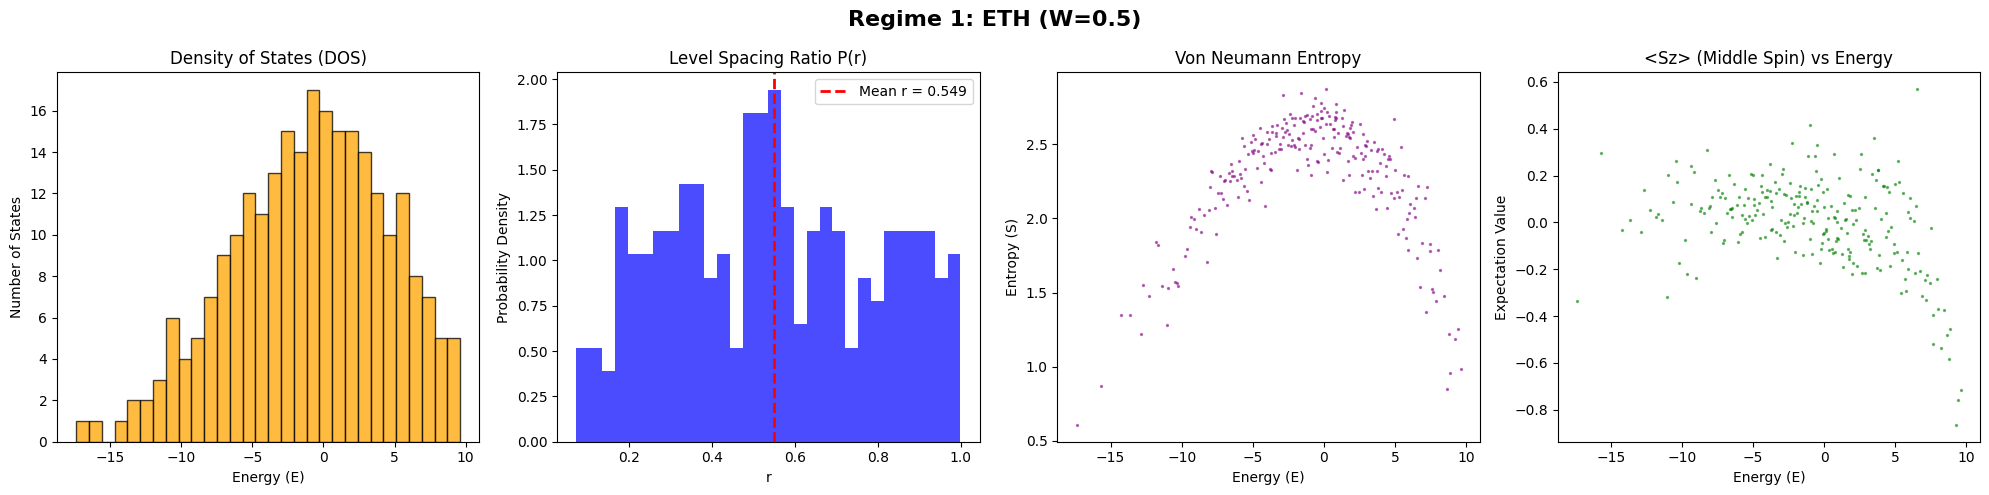


--- Starting Simulation for Regime 2: MBL (W=5.0) ---
Diagonalizing reduced Hamiltonian of size 252x252...

--- EIGENVALUE ANALYSIS ---
Ground State Energy (E_0): -28.9059
First Excited State (E_1): -27.3521
Energy Gap (Delta E):      1.5538
Highest Energy State:      29.2750
---------------------------

Calculating Observables and Entropy for all states...


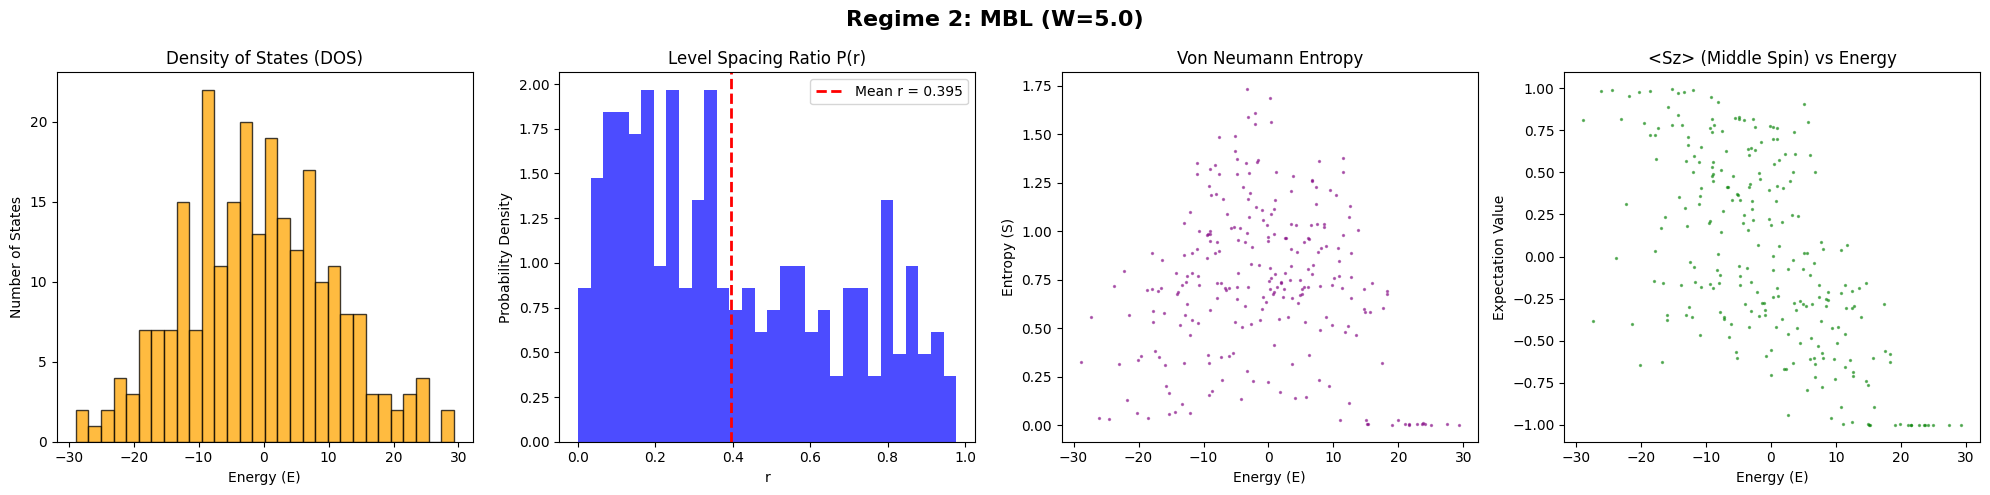

In [11]:
# run_simulations.py
import matplotlib.pyplot as plt
import numpy as np

def simulate_and_plot(L, J, Delta, W, title):
    print(f"\n--- Starting Simulation for {title} ---")
    H = build_hamiltonian(L, J, Delta, W)
    E, V = diagonalize(H, L)

    # --- 1. NEW: EIGENVALUE REPORT ---
    print("\n--- EIGENVALUE ANALYSIS ---")
    print(f"Ground State Energy (E_0): {E[0]:.4f}")
    print(f"First Excited State (E_1): {E[1]:.4f}")
    print(f"Energy Gap (Delta E):      {E[1] - E[0]:.4f}")
    print(f"Highest Energy State:      {E[-1]:.4f}")
    print("---------------------------\n")

    r_vals = calc_r_parameter(E)
    sz_vals, entropies = calc_expectation_values(E, V, L)

    # --- 2. PLOTTING (Now a 4-Panel Masterpiece) ---
    plt.figure(figsize=(20, 5)) # Made it wider to fit 4 graphs

    # Panel 1: Density of States (DOS)
    plt.subplot(1, 4, 1)
    plt.hist(E, bins=30, color='orange', alpha=0.75, edgecolor='black')
    plt.title("Density of States (DOS)")
    plt.xlabel("Energy (E)")
    plt.ylabel("Number of States")

    # Panel 2: Level Statistics
    plt.subplot(1, 4, 2)
    plt.hist(r_vals, bins=30, density=True, alpha=0.7, color='blue')
    plt.axvline(x=np.mean(r_vals), color='r', linestyle='dashed', linewidth=2, label=f'Mean r = {np.mean(r_vals):.3f}')
    plt.title("Level Spacing Ratio P(r)")
    plt.xlabel("r")
    plt.ylabel("Probability Density")
    plt.legend()

    # Panel 3: Entanglement Entropy
    plt.subplot(1, 4, 3)
    plt.scatter(E, entropies, s=2, color='purple', alpha=0.5)
    plt.title("Von Neumann Entropy")
    plt.xlabel("Energy (E)")
    plt.ylabel("Entropy (S)")

    # Panel 4: Local Observable
    plt.subplot(1, 4, 4)
    plt.scatter(E, sz_vals, s=2, color='green', alpha=0.5)
    plt.title("<Sz> (Middle Spin) vs Energy")
    plt.xlabel("Energy (E)")
    plt.ylabel("Expectation Value")

    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# --- SYSTEM PARAMETERS ---
L = 10
J = 1.0
Delta = 1.0

# --- RUN ETH PHASE ---
simulate_and_plot(L, J, Delta, W=0.5, title="Regime 1: ETH (W=0.5)")

# --- RUN MBL PHASE ---
simulate_and_plot(L, J, Delta, W=5.0, title="Regime 2: MBL (W=5.0)")